In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import seaborn as sns
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display, clear_output
import statsmodels.api as sm
import plotly.graph_objects as go

files = {2015: '2015.csv',
         2016: '2016.csv',
         2017: '2017.csv',
         2018: '2018.csv',
         2019: '2019.csv'}
data_frames = []

#add year column
for year, file in files.items():
    df = pd.read_csv(file)
    df['Year'] = year
    data_frames.append(df)

In [70]:
import sys
print(sys.executable)


/Users/sohandadana/ForgeSubmissions/ForgeSubmission/.venv/bin/python


In [71]:
for year, df in zip(files.keys(), data_frames):
    print(f"Year: {year}, Shape: {df.shape}")

Year: 2015, Shape: (158, 13)
Year: 2016, Shape: (157, 14)
Year: 2017, Shape: (155, 13)
Year: 2018, Shape: (156, 10)
Year: 2019, Shape: (156, 10)


In [72]:
#we see that each year has different number of columns and are named differently, so we must standardize them
for i in range(len(data_frames)):
    print(f"Columns in {files[list(files.keys())[i]]}: {data_frames[i].columns.tolist()}")

Columns in 2015.csv: ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Standard Error', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual', 'Year']
Columns in 2016.csv: ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Lower Confidence Interval', 'Upper Confidence Interval', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual', 'Year']
Columns in 2017.csv: ['Country', 'Happiness.Rank', 'Happiness.Score', 'Whisker.high', 'Whisker.low', 'Economy..GDP.per.Capita.', 'Family', 'Health..Life.Expectancy.', 'Freedom', 'Generosity', 'Trust..Government.Corruption.', 'Dystopia.Residual', 'Year']
Columns in 2018.csv: ['Overall rank', 'Country or region', 'Score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption'

In [73]:
#Because of the differences in columns, we will need to rename and select common columns across all years
#Our goal is to analyse trends from 2015 to 2019

#Final column names
finalNames = [
    "country",
    "year",
    "happiness_rank",
    "happiness_score",
    "gdp_per_capita",
    "social_support",
    "life_expectancy",
    "freedom",
    "generosity",
    "corruption",
]


In [74]:
#Now we have to remap the names for each year
rename_2015_2016 = {
    "Country": "country",
    "Year": "year",
    "Happiness Rank": "happiness_rank",
    "Happiness Score": "happiness_score",
    "Economy (GDP per Capita)": "gdp_per_capita",
    "Family": "social_support",
    "Health (Life Expectancy)": "life_expectancy",
    "Freedom": "freedom",
    "Generosity": "generosity",
    "Trust (Government Corruption)": "corruption",
}

rename_2017 = {
    "Country": "country",
    "Year": "year",
    "Happiness.Rank": "happiness_rank",
    "Happiness.Score": "happiness_score",
    "Economy..GDP.per.Capita.": "gdp_per_capita",
    "Family": "social_support",
    "Health..Life.Expectancy.": "life_expectancy",
    "Freedom": "freedom",
    "Generosity": "generosity",
    "Trust..Government.Corruption.": "corruption",
}

rename_2018_2019 = {
    "Country or region": "country",
    "Year": "year",
    "Overall rank": "happiness_rank",
    "Score": "happiness_score",
    "GDP per capita": "gdp_per_capita",
    "Social support": "social_support",
    "Healthy life expectancy": "life_expectancy",
    "Freedom to make life choices": "freedom",
    "Generosity": "generosity",
    "Perceptions of corruption": "corruption",
}

In [75]:
def standardize_year(df, year):
    if year in (2015, 2016):
        df = df.rename(columns=rename_2015_2016)
    elif year == 2017:
        df = df.rename(columns=rename_2017)
    elif year in (2018, 2019):
        df = df.rename(columns=rename_2018_2019)
    else:
        raise ValueError(f"Unexpected year: {year}")

    # keep only columns that exist in finalNames
    keep = [c for c in finalNames if c in df.columns]
    df = df[keep].copy()

    # clean types
    df["country"] = df["country"].astype(str).str.strip()
    df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")

    # convert all other columns to numeric
    for c in df.columns:
        if c not in ("country", "year"):
            df[c] = pd.to_numeric(df[c], errors="coerce")

    return df

In [76]:
#Standardize dataframe and combine
standardized = []
for y, df in zip(files.keys(), data_frames): 
    standardized.append(standardize_year(df, y))

happiness = pd.concat(standardized, ignore_index=True)

# Average any country duplicates between years
happiness = (happiness.groupby(["country", "year"], as_index=False).mean(numeric_only=True))

print("Merged shape:", happiness.shape)
print("Years:", sorted(happiness["year"].dropna().unique().tolist()))
print("Countries:", happiness["country"].nunique())

happiness.head()

Merged shape: (782, 10)
Years: [2015, 2016, 2017, 2018, 2019]
Countries: 170


,country,year,happiness_rank,happiness_score,gdp_per_capita,social_support,life_expectancy,freedom,generosity,corruption
0,Afghanistan,2015,153.0,3.575,0.319820,0.302850,0.303350,0.23414,0.365100,0.097190
1,Afghanistan,2016,154.0,3.360,0.382270,0.110370,0.173440,0.16430,0.312680,0.071120
2,Afghanistan,2017,141.0,3.794,0.401477,0.581543,0.180747,0.10618,0.311871,0.061158
3,Afghanistan,2018,145.0,3.632,0.332000,0.537000,0.255000,0.08500,0.191000,0.036000
4,Afghanistan,2019,154.0,3.203,0.350000,0.517000,0.361000,0.00000,0.158000,0.025000


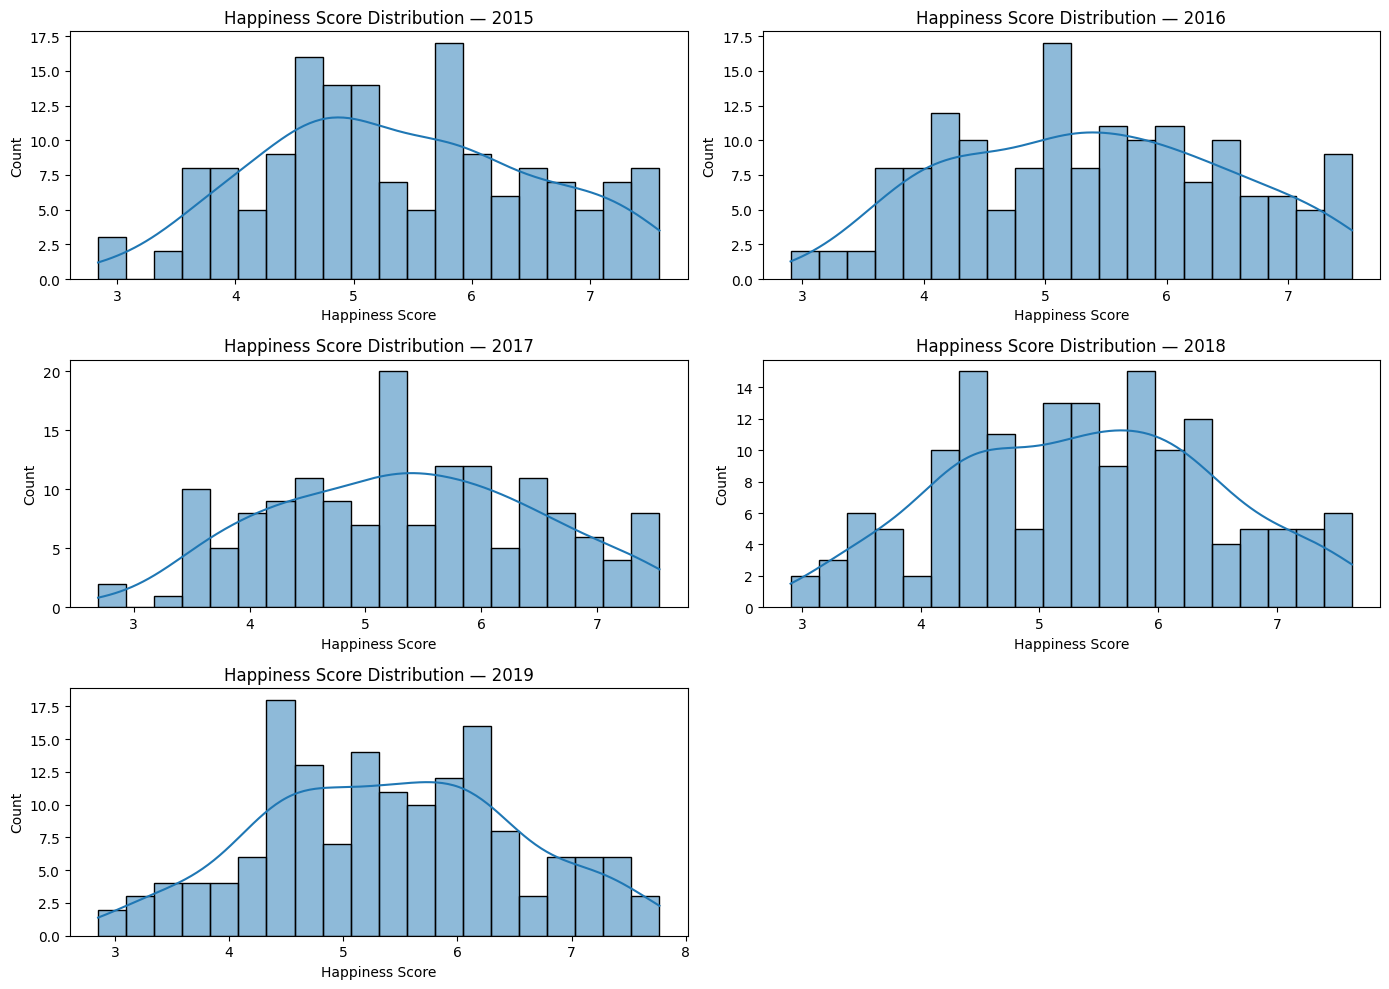

In [77]:
years = sorted(happiness["year"].unique())

plt.figure(figsize=(14, 10))

for i, year in enumerate(years, 1):
    plt.subplot(3, 2, i)
    sns.histplot(data=happiness[happiness["year"] == year], x="happiness_score", bins=20, kde=True)
    plt.title(f"Happiness Score Distribution — {year}")
    plt.xlabel("Happiness Score")
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [78]:
# Drop missing values
gdp_happiness = happiness.dropna(subset=["gdp_per_capita", "happiness_score", "country", "year"])

#plot formatting and layout
gdp_happiness["year"] = gdp_happiness["year"].astype(str)  # or .astype("category")
fig = px.scatter(
    gdp_happiness,
    x="gdp_per_capita",
    y="happiness_score",
    color="year",
    hover_name="country",
    hover_data={
        "year": True,
        "gdp_per_capita": ':.2f',
        "happiness_score": ':.2f'
    },
    labels={
        "gdp_per_capita": "GDP per Capita (Contribution Score)",
        "happiness_score": "Happiness Score"
    },
    title="GDP per Capita vs Happiness Score (2015–2019)")



In [82]:


fig.update_traces(marker=dict(size=8, opacity=0.7))
fig.update_layout(template="plotly_white")

#Gets x and y values
x = gdp_happiness["gdp_per_capita"].astype(float)
y = gdp_happiness["happiness_score"].astype(float)

#Fit a linear model
m, b = np.polyfit(x, y, 1)
y_pred = m * x + b

#Variance
ss_total = ((y - y.mean()) ** 2).sum()
ss_residual = ((y - y_pred) ** 2).sum()

#r squared
r_squared = 1 - (ss_residual / ss_total)

print(f"R² = {r_squared:.3f}")

# best-fit line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = m * x_line + b

fig.add_trace(
    go.Scatter(
        x=x_line,y=y_line,mode="lines",
        name=f"Best fit (slope={m:.3f})",
        line=dict(color="black", width=2, dash="dash")))

#renders the plot in a browser window
fig.show(renderer="browser")

R² = 0.623


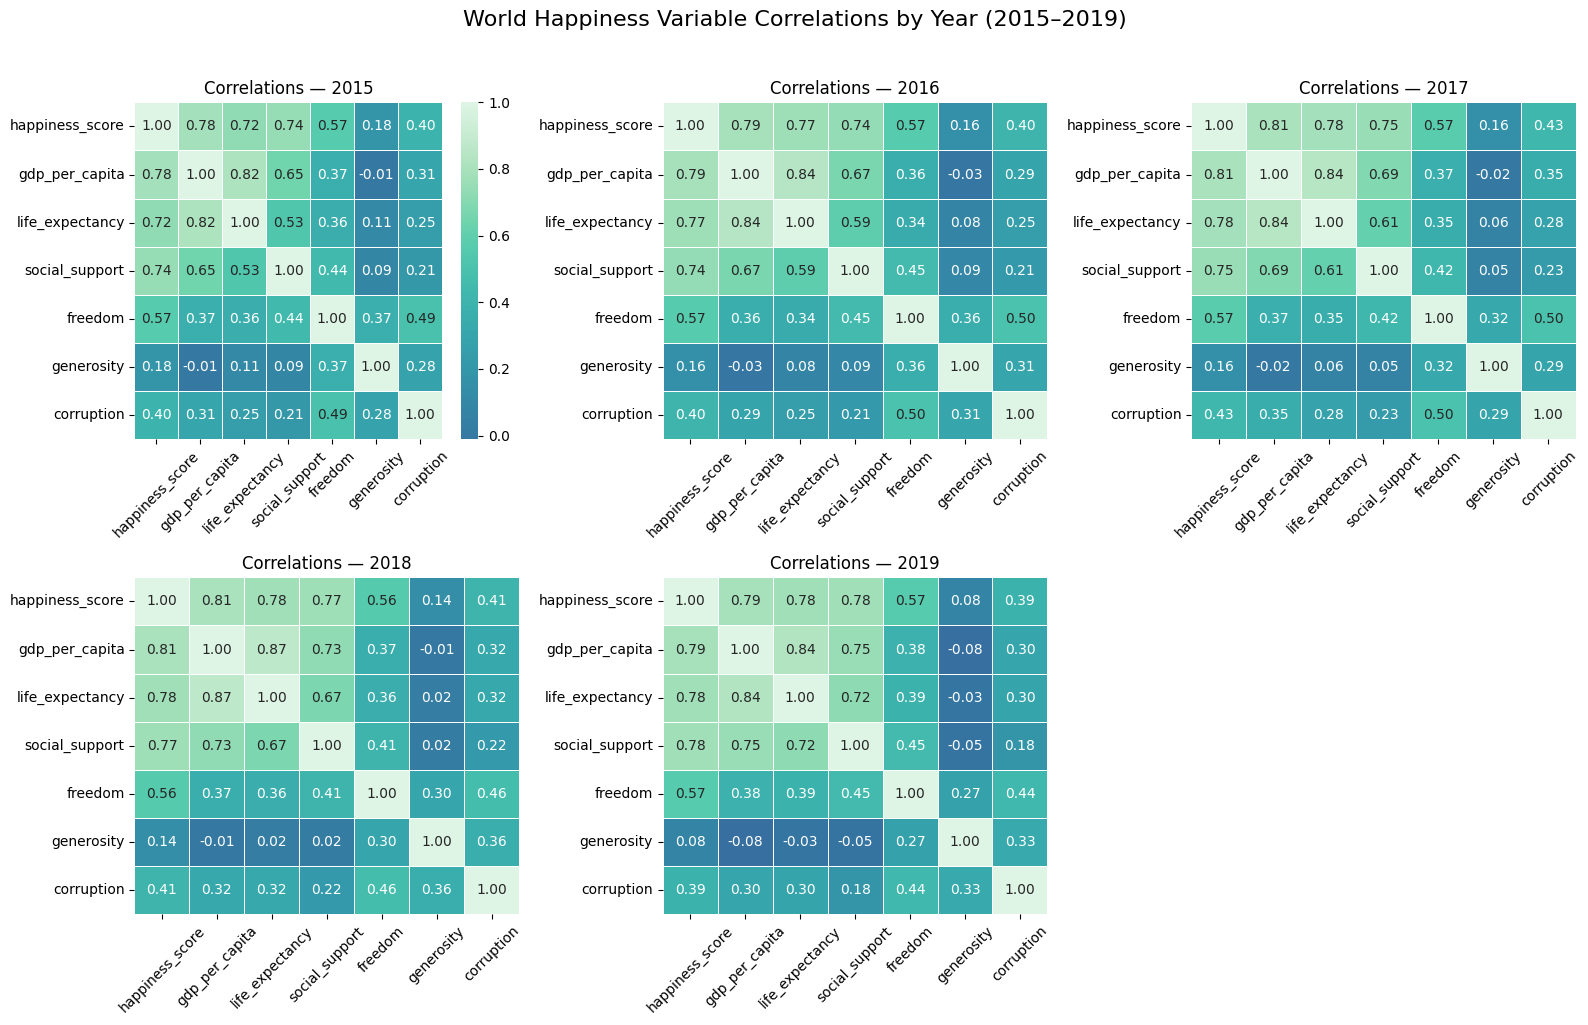

In [83]:
#Variables for correlation analysis
vars_for_corr = [
    "happiness_score", "gdp_per_capita",
    "life_expectancy", "social_support",
    "freedom", "generosity",
    "corruption",
]

# Keep only columns that exist in the dataframe
vars_for_corr = [v for v in vars_for_corr if v in happiness.columns]
years = sorted(happiness["year"].dropna().unique())

#Create subplots for each year
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

#Creates a heatmap for each year
for i, year in enumerate(years):
    ax = axes[i]
    df_year = happiness[happiness["year"] == year][vars_for_corr].dropna()

    corr = df_year.corr(numeric_only=True)

    sns.heatmap(
        corr, ax=ax,
        annot=True, fmt=".2f",
        cmap="mako", center=0,
        linewidths=0.5, cbar=(i == 0)  # show colorbar only once to reduce clutter
    )
    #Sets the title and tick parameters
    ax.set_title(f"Correlations — {year}")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

#remove the last unused subplot
for j in range(len(years), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("World Happiness Variable Correlations by Year (2015–2019)", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()


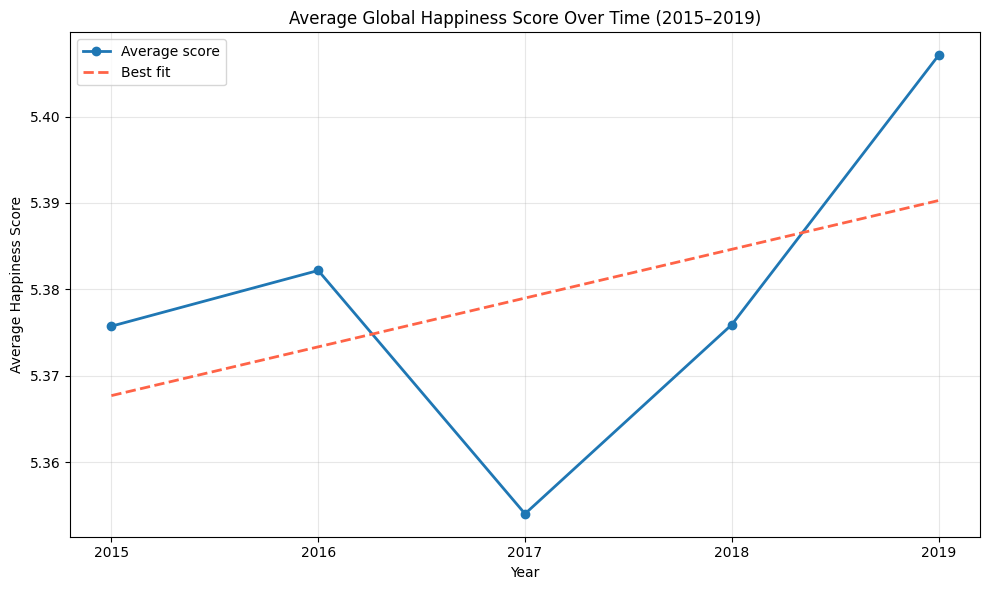

In [84]:
# get average happiness score per year
avg_happiness_by_year = (happiness.groupby("year")["happiness_score"].mean().reset_index())

plt.figure(figsize=(10, 6))

plt.plot(
    avg_happiness_by_year["year"], avg_happiness_by_year["happiness_score"],
    marker="o", linewidth=2, label="Average score")

# line of best fit
x = avg_happiness_by_year["year"]
y = avg_happiness_by_year["happiness_score"]
coef = np.polyfit(x, y, 1)
trend = np.poly1d(coef)
plt.plot(x, trend(x), linestyle="--", color="tomato", linewidth=2, label="Best fit")

plt.title("Average Global Happiness Score Over Time (2015–2019)")
plt.xlabel("Year")
plt.ylabel("Average Happiness Score")
plt.xticks(avg_happiness_by_year["year"])
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [85]:
#Base data for each country trajectory plot
traj = happiness.dropna(subset=["country", "year", "happiness_score"]).copy()
traj["year"] = traj["year"].astype(int)
all_countries = sorted(traj["country"].unique().tolist())

#Search functionality; allows user to search and select countries to plot
search = widgets.Text(
    value="",
    placeholder="Type to search countries (e.g., 'India', 'Japan', 'Iran')",
    description="Search:", layout=widgets.Layout(width="500px"))

country_select = widgets.SelectMultiple(
    options=all_countries,
    value=tuple(all_countries[:3]), 
    description="Countries:", layout=widgets.Layout(width="500px", height="220px")
)
out = widgets.Output()

#Function to update country options based on search input
def update_options(change=None):
    q = search.value.strip().lower()
    if q == "":
        filtered = all_countries
    else:
        filtered = [c for c in all_countries if q in c.lower()]

    #Keep current selections if still valid
    current = set(country_select.value)
    new_value = tuple([c for c in filtered if c in current])

    #Default to first 3 if none selected
    country_select.options = filtered
    country_select.value = new_value if len(new_value) > 0 else tuple(filtered[:min(3, len(filtered))])

In [86]:
#Function to plot selected countries
def plot_selected(change=None):
    with out:
        clear_output(wait=True)

        selected = list(country_select.value)
        if not selected:
            print("Select at least one country to plot.")
            return
        #Filter data for selected countries
        df = traj[traj["country"].isin(selected)].sort_values(["country", "year"])

        #plots the line and formats it
        fig = px.line(
            df, x="year", y="happiness_score",
            color="country", markers=True, hover_name="country",
            hover_data={"year": True, "happiness_score":":.2f"},
            labels={"year":"Year", "happiness_score":"Happiness Score", "country":"Country"},
            title="Country-Level Happiness Trajectories (2015–2019)")

        fig.update_layout(
            template="plotly_white", hovermode="x unified",
            legend_title_text="Country")

        #Renders plot in browser
        fig.show(renderer="browser")

#Defines the user interactions
search.observe(lambda ch: update_options(), names="value")
country_select.observe(lambda ch: plot_selected(), names="value")

# Initialize
update_options()
plot_selected()

display(widgets.VBox([search, country_select, out]))

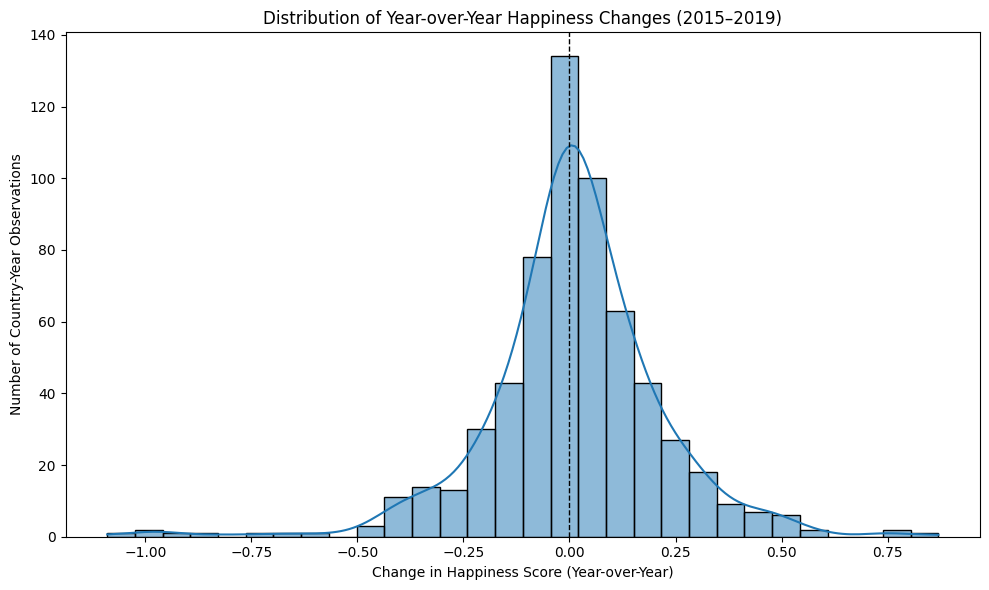

In [87]:
#Get yearly change for each country
growth = (
    happiness.sort_values(["country", "year"]).groupby("country", as_index=False).apply(lambda df: 
    df.assign(happiness_yoy_growth=df["happiness_score"].diff())).reset_index(drop=True))

#Drop the first year for each country since it has no growth value
growth_clean = growth.dropna(subset=["happiness_yoy_growth"])

#Plot distribution of year-over-year happiness changes
plt.figure(figsize=(10, 6))

sns.histplot(data=growth_clean,x="happiness_yoy_growth", bins=30, kde=True)

plt.axvline(0, linestyle="--", linewidth=1, color="black")
plt.title("Distribution of Year-over-Year Happiness Changes (2015–2019)")
plt.xlabel("Change in Happiness Score (Year-over-Year)")
plt.ylabel("Number of Country-Year Observations")
plt.tight_layout()

plt.show()

In [88]:
#Find countries that consistently perform above the global median happiness score
tmp = happiness.dropna(subset=["country", "year", "happiness_score"]).copy()

#Get global median happiness score for each year
year_median = tmp.groupby("year")["happiness_score"].median().rename("year_median")
tmp = tmp.merge(year_median, on="year", how="left")

#Indicate if above median for that year
tmp["above_year_median"] = (tmp["happiness_score"] >= tmp["year_median"]).astype(int)

#number of years above median (0–5)
duration = (tmp.groupby("country")["above_year_median"].sum().rename("duration_above_median").reset_index())

# avg happiness score per country across all years
avg_hap = (tmp.groupby("country")["happiness_score"].mean().rename("avg_happiness").reset_index())
country_persistence = duration.merge(avg_hap, on="country", how="inner")



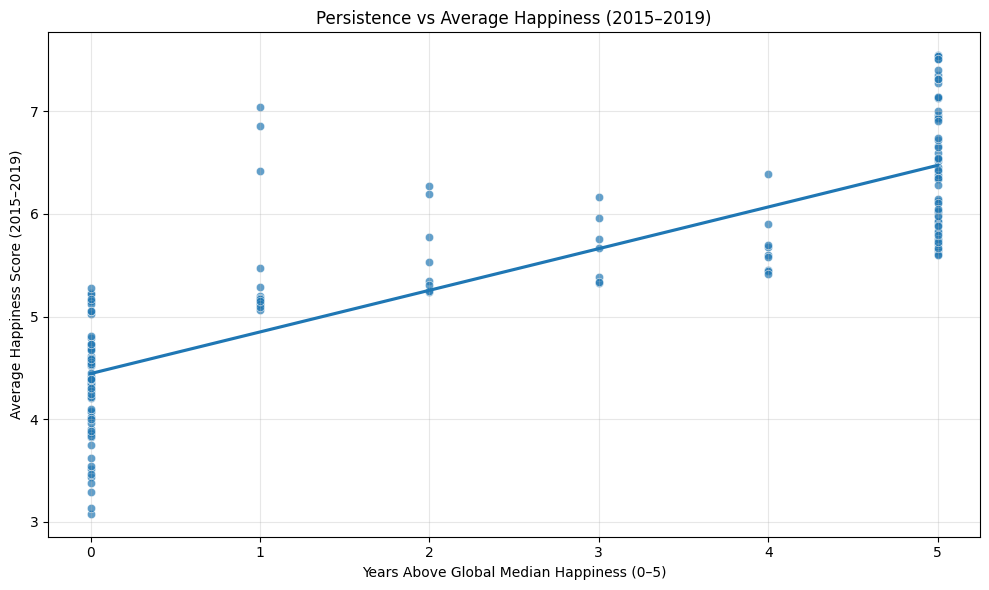

In [89]:
#Plot duration vs avg happiness
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=country_persistence, x="duration_above_median",
    y="avg_happiness", alpha=0.7)

#Trend line
sns.regplot(
    data=country_persistence,
    x="duration_above_median",
    y="avg_happiness", scatter=False, ci=None)

plt.title("Persistence vs Average Happiness (2015–2019)")
plt.xlabel("Years Above Global Median Happiness (0–5)")
plt.ylabel("Average Happiness Score (2015–2019)")
plt.xticks(range(0, 6))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [90]:
country_persistence.sort_values(["duration_above_median", "avg_happiness"], ascending=[False, False]).head(10)


,country,duration_above_median,avg_happiness
38,Denmark,5,7.5460
111,Norway,5,7.5410
46,Finland,5,7.5378
145,Switzerland,5,7.5114
61,Iceland,5,7.5110
103,Netherlands,5,7.4046
25,Canada,5,7.3506
144,Sweden,5,7.3192
104,New Zealand,5,7.3130
6,Australia,5,7.2762


In [91]:
country_persistence.sort_values(["duration_above_median", "avg_happiness"], ascending=[False, False]).tail(10)

,country,duration_above_median,avg_happiness
87,Madagascar,0,3.74540
167,Yemen,0,3.62580
152,Togo,0,3.54420
0,Afghanistan,0,3.51280
150,Tanzania,0,3.46600
125,Rwanda,0,3.43860
138,South Sudan,0,3.38250
146,Syria,0,3.29220
26,Central African Republic,0,3.13425
22,Burundi,0,3.07900


In [92]:
#Select variables for regression analysis
regression_vars = [
    "happiness_score",
    "gdp_per_capita",
    "life_expectancy",
    "social_support",
    "freedom",
    "generosity",
    "corruption",
]

#drop missing values
df_reg = happiness[regression_vars].dropna()

#Separate independent and dependent variables
X = df_reg.drop(columns="happiness_score")
y = df_reg["happiness_score"]

#Add x intercept
X = sm.add_constant(X)

#fit a simple OLS regression model
model = sm.OLS(y, X).fit()

model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        happiness_score   R-squared:                       0.764
Model:                            OLS   Adj. R-squared:                  0.762
Method:                 Least Squares   F-statistic:                     417.0
Date:                Fri, 30 Jan 2026   Prob (F-statistic):          1.42e-238
Time:                        15:38:08   Log-Likelihood:                -637.71
No. Observations:                 781   AIC:                             1289.
Df Residuals:                     774   BIC:                             1322.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               2.1751      0.080     27.219      0.000       2.018       2.332
gdp_per_capita      1.1360      0.084     13.500      0.000       0.971       1.301
life_expectancy     1.0127      0.132      7.671      0.000       0.754       1.272
social_support      0.6459      0.081      7.982      0.000       0.487       0.805
freedom             1.4813      0.163      9.062      0.000       1.160       1.802
generosity          0.5924      0.176      3.372      0.001       0.248       0.937
corruption          0.8582      0.223      3.841      0.000       0.420       1.297
==============================================================================
Omnibus:                       16.196   Durbin-Watson:                   0.731
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               18.249
Skew:                          -0.285   Prob(JB):                     0.000109
Kurtosis:                       3.486   Cond. No.                         23.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

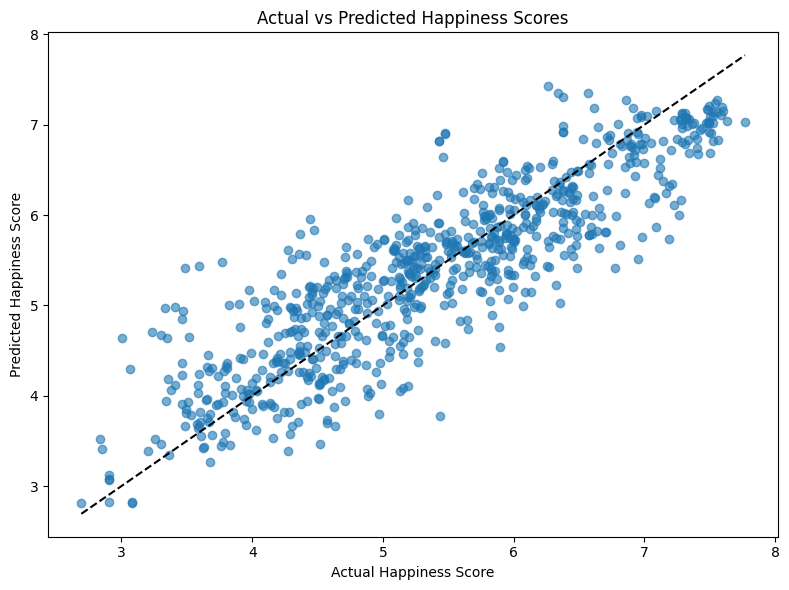

In [93]:
df_reg["predicted_happiness"] = model.predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(df_reg["happiness_score"], df_reg["predicted_happiness"], alpha=0.6)
plt.plot(
    [df_reg["happiness_score"].min(), df_reg["happiness_score"].max()],
    [df_reg["happiness_score"].min(), df_reg["happiness_score"].max()],
    linestyle="--",
    color="black"
)

plt.xlabel("Actual Happiness Score")
plt.ylabel("Predicted Happiness Score")
plt.title("Actual vs Predicted Happiness Scores")
plt.tight_layout()
plt.show()
